## 3 – Độ đo Statistical Distance & Phát hiện Outliers

### 1. Độ đo Euclid
### 2. Statistical Distance 
### 3. Khoảng cách Mahalanobis — phát hiện outlier
### 4. Trực quan và bàn luận ý nghĩa hình học

In [12]:
# Bước 1: Nhập thư viện và dữ liệu, tính toán mean, std, variance
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

sys.path.append(os.path.abspath('..'))
from source.utils import mean, standard_deviation, euclidean_distance, statistical_distance

df = pd.read_csv('../data/WineQT.csv', sep=',')
features = df.drop(columns=['quality', 'Id'])
var_list = features.columns.tolist()

pop_mean = np.array([mean(features[col]) for col in var_list])
pop_std  = np.array([standard_deviation(features[col], is_population=True) for col in var_list])
pop_var = pop_std ** 2

print(f"p = {len(var_list)} biến")
print(f"n = {len(features)} mẫu")

p = 11 biến
n = 1143 mẫu


## Độ đo Euclid

$$d_E(P, Q) = \sqrt{\sum_{k=1}^{p}(x_k - y_k)^2}$$

Khoảng cách Euclid **không tính đến thang đo** của từng biến.  
Biến có phương sai lớn sẽ **áp đảo** khoảng cách.

In [ ]:
# Bước 2: Tính khoảng cách Euclid cho một mẫu
# Dữ liệu thô không chuẩn hóa - các biến có phương sai lớn sẽ áp đảo khoảng cách
p = features.iloc[0].values
q = pop_mean

d_euclidean = euclidean_distance(p, q)
print(f"Khoảng cách Euclidean giữa p và q: {d_euclidean:.4f}")
print(f"So sánh thành phần đóng góp vào khoảng cách Euclid:")

contributions = (p - q) ** 2
for c, v, cont in zip(var_list, p, contributions):
    bar = "█" * int(cont / max(contributions) * 30)
    print(f"  {c:25s} diff={v - q[var_list.index(c)]:+.2f}  contrib={cont:.2f}  {bar}")

Mẫu p: [ 7.4     0.7     0.      1.9     0.076  11.     34.      0.9978  3.51
  0.56    9.4   ]
Mean q: [ 8.31111111  0.53133858  0.26836395  2.53215223  0.08693263 15.61548556
 45.91469816  0.99673041  3.31101487  0.65770779 10.4421114 ]
Khoảng cách Euclidean giữa p và q: 12.8735
So sánh thành phần đóng góp vào khoảng cách Euclid:

[8.30123457e-01 2.84466737e-02 7.20192121e-02 3.99616443e-01
 1.19522474e-04 2.13027070e+01 1.41960032e+02 1.14402020e-06
 3.95950807e-02 9.54681155e-03 1.08599618e+00]

  fixed acidity             diff=-0.91  contrib=0.83  
  volatile acidity          diff=+0.17  contrib=0.03  
  citric acid               diff=-0.27  contrib=0.07  
  residual sugar            diff=-0.63  contrib=0.40  
  chlorides                 diff=-0.01  contrib=0.00  
  free sulfur dioxide       diff=-4.62  contrib=21.30  ████
  total sulfur dioxide      diff=-11.91  contrib=141.96  ██████████████████████████████
  density                   diff=+0.00  contrib=0.00  
  pH             

## Statistical Distance

**Chuẩn hóa từng chiều:**
$$d_S(P, Q) = \sqrt{\sum_{k=1}^{p} \frac{(x_k - y_k)^2}{s_{kk}}}$$

**Dạng tổng quát:**
$$d(P, Q) = \sqrt{(P - Q)^\top A\, (P - Q)}$$

Khi $A = S^{-1}$ (nghịch đảo ma trận hiệp phương sai) → **khoảng cách Mahalanobis**.


In [24]:
# Bước 3: Tính khoảng cách thống kê
# Chuẩn hóa mỗi chiều theo phương sai - các biến đóng góp công bằng hơn
d_stat = statistical_distance(p, q, pop_var)
print(f"Khoảng cách thống kê đơn giản: d_S(p, mean) = {d_stat:.4f}")
print()
print("So sánh đóng góp sau chuẩn hóa (Statistical Distance):")
contribs_s = (p - q)**2 / pop_var
for c, val, cont in zip(var_list, p - q, contribs_s):
    bar = "█" * int(cont / max(contribs_s) * 30)
    print(f"  {c:25s} (x-μ)={val:+.3f}  contrib={cont:.4f}  {bar}")


Khoảng cách thống kê đơn giản: d_S(p, mean) = 2.6086

So sánh đóng góp sau chuẩn hóa (Statistical Distance):
  fixed acidity             (x-μ)=-0.911  contrib=0.2720  ████
  volatile acidity          (x-μ)=+0.169  contrib=0.8823  ██████████████
  citric acid               (x-μ)=-0.268  contrib=1.8633  ██████████████████████████████
  residual sugar            (x-μ)=-0.632  contrib=0.2175  ███
  chlorides                 (x-μ)=-0.011  contrib=0.0535  
  free sulfur dioxide       (x-μ)=-4.615  contrib=0.2029  ███
  total sulfur dioxide      (x-μ)=-11.915  contrib=0.1322  ██
  density                   (x-μ)=+0.001  contrib=0.3090  ████
  pH                        (x-μ)=+0.199  contrib=1.6147  █████████████████████████
  sulphates                 (x-μ)=-0.098  contrib=0.3291  █████
  alcohol                   (x-μ)=-1.042  contrib=0.9281  ██████████████


## Mahalanobis Distance & Phát hiện Outliers

$$d_M^2(\mathbf{x}_j, \bar{\mathbf{x}}) = (\mathbf{x}_j - \bar{\mathbf{x}})^\top S^{-1} (\mathbf{x}_j - \bar{\mathbf{x}})$$

Theo CLT, $n \cdot (\bar{X} - \mu)^\top S^{-1} (\bar{X} - \mu) \approx \chi^2_p$.  
Ta dùng ngưỡng $\chi^2_{p, 0.975}$ để phát hiện outlier.

**Quy trình phát hiện:**
1. Tính đại lượng chuẩn hóa $z_{jk} = (x_{jk} - \bar{x}_k)/s_k$
2. Chú ý các giá trị $|z| > 3$
3. Tính khoảng cách Mahalanobis cho từng mẫu
4. Chú ý các khoảng cách bất thường lớn


In [15]:
# Bước 4: Chuẩn hóa Z-score cho từng biến
# Phát hiện những giá trị ngoài kỳ vọng (|z| > 3)
samp_means_vec = np.array([mean(features[c]) for c in var_list])
samp_stds_vec  = np.array([standard_deviation(features[c], is_population=False) for c in var_list])

Z = (features.values - samp_means_vec) / samp_stds_vec
Z_df = pd.DataFrame(Z, columns=var_list)

print("Phần trăm mẫu có |z| > 3 theo từng biến:")
for c in var_list:
    pct = (abs(Z_df[c]) > 3).mean() * 100
    bar = "█" * int(pct * 5)
    print(f"  {c:25s} {pct:.1f}%  {bar}")

Phần trăm mẫu có |z| > 3 theo từng biến:
  fixed acidity             0.8%  ███
  volatile acidity          0.4%  ██
  citric acid               0.1%  
  residual sugar            2.0%  ██████████
  chlorides                 1.8%  █████████
  free sulfur dioxide       1.1%  █████
  total sulfur dioxide      0.9%  ████
  density                   1.0%  █████
  pH                        0.4%  ██
  sulphates                 1.8%  █████████
  alcohol                   0.6%  ███


In [16]:
# Bước 5: Tính khoảng cách Mahalanobis cho tất cả mẫu
# Sử dụng ma trận hiệp phương sai để đo độ bất thường của mỗi mẫu
X = features.values.astype(float)
mu_vec = np.mean(X, axis=0)
S = np.cov(X, rowvar=False)         
S_inv = np.linalg.pinv(S)           

diff = X - mu_vec
D2 = np.einsum("ij,jk,ik->i", diff, S_inv, diff)   

p = X.shape[1]
chi2_thresh = stats.chi2.ppf(0.975, df=p)

outlier_mask = D2 > chi2_thresh
n_outliers = outlier_mask.sum()
print(f"p = {p} biến → ngưỡng χ²(p=14, α=0.025) = {chi2_thresh:.2f}")
print(f"Số mẫu vượt ngưỡng (outlier): {n_outliers}/{len(X)} = {n_outliers/len(X)*100:.1f}%")

p = 11 biến → ngưỡng χ²(p=14, α=0.025) = 21.92
Số mẫu vượt ngưỡng (outlier): 87/1143 = 7.6%


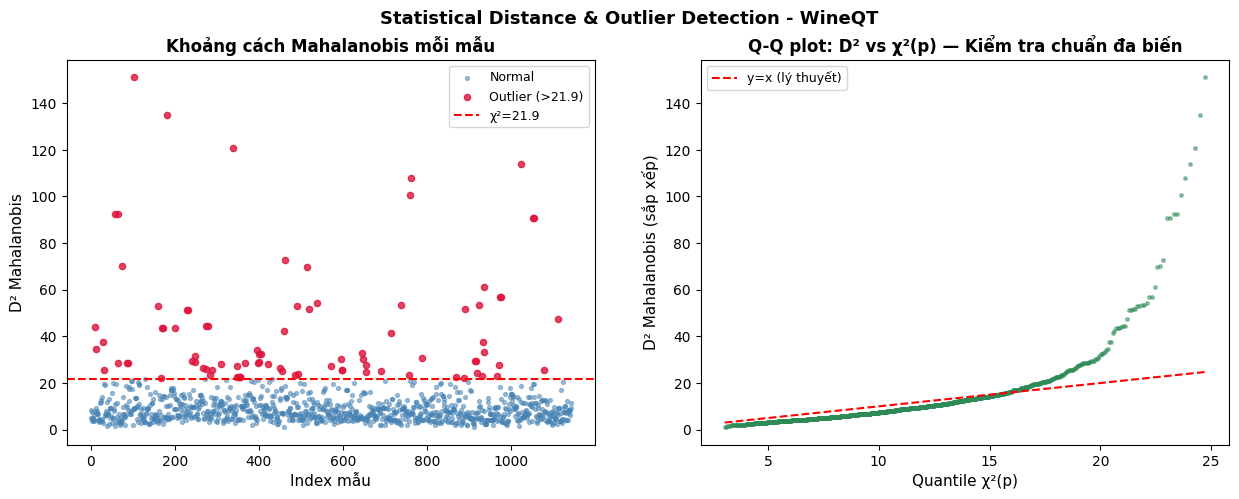

In [17]:
# Bước 6: Vẽ biểu đồ so sánh Mahalanobis distance và kiểm tra chuẩn đa biến
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.scatter(np.where(~outlier_mask)[0], D2[~outlier_mask],
           s=8, color="steelblue", alpha=0.5, label="Normal")
ax.scatter(np.where(outlier_mask)[0], D2[outlier_mask],
           s=20, color="crimson", alpha=0.8, label=f"Outlier (>{chi2_thresh:.1f})")
ax.axhline(chi2_thresh, color="red", lw=1.5, ls="--", label=f"χ²={chi2_thresh:.1f}")
ax.set_xlabel("Index mẫu", fontsize=11)
ax.set_ylabel("D² Mahalanobis", fontsize=11)
ax.set_title("Khoảng cách Mahalanobis mỗi mẫu", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)

ax2 = axes[1]
sorted_D2 = np.sort(D2)
chi2_quantiles = stats.chi2.ppf(np.linspace(0.01, 0.99, len(sorted_D2)), df=p)
ax2.scatter(chi2_quantiles, sorted_D2, s=6, alpha=0.5, color="seagreen")
ax2.plot([chi2_quantiles[0], chi2_quantiles[-1]],
         [chi2_quantiles[0], chi2_quantiles[-1]], "r--", lw=1.5, label="y=x (lý thuyết)")
ax2.set_xlabel("Quantile χ²(p)", fontsize=11)
ax2.set_ylabel("D² Mahalanobis (sắp xếp)", fontsize=11)
ax2.set_title("Q-Q plot: D² vs χ²(p) — Kiểm tra chuẩn đa biến", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)

plt.suptitle("Statistical Distance & Outlier Detection - WineQT", fontsize=13, fontweight="bold")
plt.show()

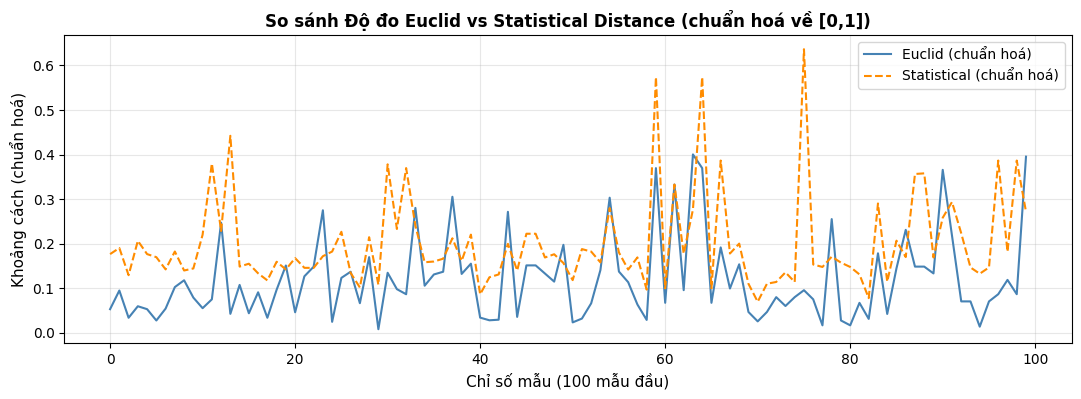

In [18]:
# Bước 7: So sánh độ đo Euclid vs Statistical Distance
# Trực quan hóa sự khác biệt khi không chuẩn hóa vs chuẩn hóa theo phương sai
n_show = 100
d_euclid_all = np.sqrt(np.sum((X - mu_vec)**2, axis=1))
d_stat_all   = np.sqrt(np.sum((X - mu_vec)**2 / pop_var, axis=1))

de_norm = d_euclid_all[:n_show] / d_euclid_all.max()
ds_norm = d_stat_all[:n_show] / d_stat_all.max()

fig, ax = plt.subplots(figsize=(13, 4))
x_idx = np.arange(n_show)
ax.plot(x_idx, de_norm, color="steelblue", lw=1.5, label="Euclid (chuẩn hoá)")
ax.plot(x_idx, ds_norm, color="darkorange", lw=1.5, ls="--", label="Statistical (chuẩn hoá)")
ax.set_xlabel("Chỉ số mẫu (100 mẫu đầu)", fontsize=11)
ax.set_ylabel("Khoảng cách (chuẩn hoá)", fontsize=11)
ax.set_title("So sánh Độ đo Euclid vs Statistical Distance (chuẩn hoá về [0,1])", 
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.show()

In [19]:
# Bước 8: Hiển thị các outliers được phát hiện
# Những mẫu có Mahalanobis distance vượt ngưỡng χ² được xem là bất thường
outlier_df = features[outlier_mask].copy()
outlier_df["D2_Mahalanobis"] = D2[outlier_mask]
outlier_df["quality"] = df.loc[outlier_mask, "quality"].values
outlier_df = outlier_df.sort_values("D2_Mahalanobis", ascending=False)

print(f"Top 10 outliers (theo D² Mahalanobis):")
print(outlier_df[["alcohol", "volatile acidity", "total sulfur dioxide", 
                   "pH", "D2_Mahalanobis", "quality"]].head(10).to_string())

Top 10 outliers (theo D² Mahalanobis):
      alcohol  volatile acidity  total sulfur dioxide    pH  D2_Mahalanobis  quality
103       9.4              0.52                  69.0  2.74      151.089717        4
182       9.4              0.41                  45.0  3.06      134.732514        5
339       9.2              0.28                  23.0  3.12      120.699214        5
1022      9.0              0.54                  95.0  3.18      113.951988        6
761      12.3              0.30                 289.0  3.01      107.872024        7
760      12.3              0.30                 278.0  3.01      100.672541        7
59        9.9              0.49                 136.0  2.93       92.452908        6
64        9.9              0.49                 136.0  2.93       92.452908        6
1051      8.8              0.50                  82.0  3.16       90.781210        5
1053      8.8              0.50                  82.0  3.16       90.781210        5
